# RescueLink AI - Training & Evaluation Notebook
This notebook trains and evaluates the emergency classification model, visualizes accuracy, and saves artifacts.
This notebook will guide you step by step:
1. Load the dataset
2. Tokenize the text
3. Train the model
4. Evaluate accuracy
5. Visualize results



In [14]:
# Standard library
import os
import ast
import json

# Data handling
import pandas as pd
import numpy as np

# PyTorch
import torch
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers (multilingual backbone + tokenizer)
from transformers import AutoTokenizer

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support
)

# Project modules
from models.emergency_classifier import EmergencyClassifier
from training.train import EmergencyDataset

## Step 0: Load Latest Trained Model

Before training, we check if a saved model file (`models/emergency_model.pt`) exists.  
- If it does, we load the weights into our `EmergencyClassifier` so we can continue training or run inference without starting from scratch.  
- If not, we initialize a fresh model.


In [15]:
import json

MODEL_PATH = "models/emergency_model.pt"
META_PATH = "models/label_meta.json"

# Expected architecture for merged dataset
EXPECTED_INCIDENT_TYPES = ["Accident", "Crime", "Fire", "Medical", "Natural Disaster", "Other"]
EXPECTED_SEVERITY_LABELS = ["Green", "Yellow", "Red", "Black"]

def load_metadata():
    if os.path.exists(META_PATH):
        with open(META_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return {
            "incident_type_labels": checkpoint.get("incident_type_labels"),
            "severity_labels": checkpoint.get("severity_labels"),
            "backbone": checkpoint.get("backbone", "xlm-roberta-base"),
            "threshold": checkpoint.get("threshold", 0.5),
        }
    raise ValueError("Metadata not found.")

# Check if saved model exists and matches architecture
if os.path.exists(MODEL_PATH):
    try:
        meta = load_metadata()
        tokenizer = AutoTokenizer.from_pretrained(meta.get("backbone", "xlm-roberta-base"))
        
        # Check architecture compatibility
        architecture_match = (
            meta["incident_type_labels"] == EXPECTED_INCIDENT_TYPES and
            meta["severity_labels"] == EXPECTED_SEVERITY_LABELS
        )
        
        if architecture_match:
            model = EmergencyClassifier(
                num_incident_types=len(meta["incident_type_labels"]),
                num_severity_classes=len(meta["severity_labels"]),
                backbone=meta.get("backbone", "xlm-roberta-base"),
            )
            checkpoint = torch.load(MODEL_PATH, map_location="cpu")
            state_dict = checkpoint.get("model_state_dict") if isinstance(checkpoint, dict) else checkpoint
            model.load_state_dict(state_dict)
            model.eval()
            print("✓ Loaded existing model with compatible architecture")
        else:
            print("⚠ Architecture mismatch → Training fresh model")
            meta = {
                "incident_type_labels": EXPECTED_INCIDENT_TYPES,
                "severity_labels": EXPECTED_SEVERITY_LABELS,
                "backbone": "xlm-roberta-base",
                "threshold": 0.5,
            }
            model = None
    except Exception as e:
        print(f"⚠ Error loading: {e} → Training fresh")
        meta = {
            "incident_type_labels": EXPECTED_INCIDENT_TYPES,
            "severity_labels": EXPECTED_SEVERITY_LABELS,
            "backbone": "xlm-roberta-base",
            "threshold": 0.5,
        }
        tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
        model = None
else:
    print("No saved model → Training fresh")
    meta = {
        "incident_type_labels": EXPECTED_INCIDENT_TYPES,
        "severity_labels": EXPECTED_SEVERITY_LABELS,
        "backbone": "xlm-roberta-base",
        "threshold": 0.5,
    }
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    model = None

print(f"\nArchitecture: {len(meta['incident_type_labels'])} incident types, {len(meta['severity_labels'])} severity levels")
print(f"Labels: {meta['incident_type_labels']}")

⚠ Architecture mismatch → Training fresh model

Architecture: 6 incident types, 4 severity levels
Labels: ['Accident', 'Crime', 'Fire', 'Medical', 'Natural Disaster', 'Other']


## Step 1: Load the Dataset
Run the next cell to load the emergency dataset from `data/emergency_dataset.csv`.
We’ll split it into training and validation sets.


In [16]:
# Load the HIGH-QUALITY SYNTHETIC dataset (15k rows, Filipino-prioritized)
df = pd.read_csv("data/emergency_dataset.csv")

# Parse string representations back to lists
df["incident_types"] = df["incident_types"].apply(ast.literal_eval)
df["type_labels"] = df["type_labels"].apply(ast.literal_eval)
df["severity_label"] = df["severity_label"].astype(int)

# Split into train/val (80/20)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["severity_label"])

print("HIGH-QUALITY SYNTHETIC DATASET (15k rows):")
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Total: {len(df)}")

# Language distribution
print("\nLanguage Distribution (Train):")
print(train_df["lang"].value_counts())

# Severity distribution
severity_map = {0: "Green", 1: "Yellow", 2: "Red", 3: "Black"}
print("\nSeverity Distribution (Train):")
for label in sorted(train_df["severity_label"].unique()):
    count = (train_df["severity_label"] == label).sum()
    print(f"  {severity_map[label]}: {count} ({count/len(train_df)*100:.1f}%)")

print("\nSample Filipino reports:")
for i, row in train_df[train_df["lang"] == "fil"].head(3).iterrows():
    print(f"  {row['text']}")


HIGH-QUALITY SYNTHETIC DATASET (15k rows):
Train size: 12000
Validation size: 3000
Total: 15000

Language Distribution (Train):
lang
fil    9648
en     2352
Name: count, dtype: int64

Severity Distribution (Train):
  Green: 3049 (25.4%)
  Yellow: 2913 (24.3%)
  Red: 2964 (24.7%)
  Black: 3074 (25.6%)

Sample Filipino reports:
  Nag-report ng nahimatay, critical na.
  Emergency. nagliliyab na bahay at basag na rehistro, medyo masakit.
  Nag-report ng tagas ng tubig, hindi na umaandar.


In [17]:
## Step 1.5: Dataset Diagnostics

# Check dataset size
print("=" * 60)
print("DATASET DIAGNOSTICS")
print("=" * 60)
print(f"Dataset size: {len(df)}")

# Check average text length
print(f"Avg text length: {df['text'].str.len().mean():.0f} chars")
print(f"Min text length: {df['text'].str.len().min()} chars")
print(f"Max text length: {df['text'].str.len().max()} chars")

# Check labels per row (type_labels already parsed as lists)
if isinstance(df['type_labels'].iloc[0], list):
    print(f"\nAvg labels per row: {df['type_labels'].apply(len).mean():.2f}")
    print(f"Label distribution:")
    label_counts = df["type_labels"].apply(len).value_counts().sort_index()
    for num_labels, count in label_counts.items():
        print(f"  {num_labels} label(s): {count} rows ({count/len(df)*100:.1f}%)")
else:
    # Parse if still strings
    df["type_labels"] = df["type_labels"].apply(ast.literal_eval)
    print(f"\nAvg labels per row: {df['type_labels'].apply(len).mean():.2f}")

# Check GPU memory
print(f"\n{'GPU MEMORY':^60}")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"GPU device: {torch.cuda.get_device_name(0)}")
print("=" * 60)

DATASET DIAGNOSTICS
Dataset size: 15000
Avg text length: 49 chars
Min text length: 14 chars
Max text length: 112 chars

Avg labels per row: 1.30
Label distribution:
  1 label(s): 10510 rows (70.1%)
  2 label(s): 4490 rows (29.9%)

                         GPU MEMORY                         
GPU memory used: 4.46 GB
GPU memory reserved: 5.88 GB
GPU device: NVIDIA GeForce RTX 4050 Laptop GPU


## Step 2: Tokenization
Run this cell to convert text into numerical tokens using DistilBERT’s tokenizer.
This prepares the data for the model.


In [18]:
# Use XLM-RoBERTa tokenizer for multilingual support
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Tokenize training and validation sets
train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)
val_encodings = tokenizer(
    val_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [19]:
# Note: use "type_labels" (plural) since each row may have multiple incident types
train_dataset = EmergencyDataset(
    train_encodings, 
    train_df["type_labels"].tolist(), 
    train_df["severity_label"].tolist(),
    num_types=len(meta["incident_type_labels"])
)
val_dataset = EmergencyDataset(
    val_encodings, 
    val_df["type_labels"].tolist(), 
    val_df["severity_label"].tolist(),
    num_types=len(meta["incident_type_labels"])
)

# Optimization: pin_memory for faster GPU transfer (disable num_workers for now)
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True, 
    pin_memory=True,  # Faster GPU transfer
    num_workers=0      # No multiprocessing (avoids stale data issues)
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=16,
    pin_memory=True,
    num_workers=0
)

## Step 3: Training Loop
Run this cell to train the EmergencyClassifier model.
You’ll see training and validation loss after each epoch.


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a fresh model with correct parameters
model = EmergencyClassifier(
    num_incident_types=len(meta["incident_type_labels"]),
    num_severity_classes=len(meta["severity_labels"]),
    backbone=meta.get("backbone", "xlm-roberta-base"),
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Add scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

# Optimization: Mixed precision training with autocast and GradScaler
scaler = torch.amp.GradScaler('cuda')

train_losses, val_losses = [], []

# Loss functions
bce_loss = torch.nn.BCEWithLogitsLoss()                     # multi-label incident types
ce_loss_severity = torch.nn.CrossEntropyLoss(label_smoothing=0.1)  # severity with smoothing

num_incident_types = len(meta["incident_type_labels"])

for epoch in range(5):  # increase epochs to see scheduler effect
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Mixed precision forward pass
        with torch.amp.autocast('cuda'):
            outputs = model(input_ids, attention_mask)

            # Multi-label incident type loss
            loss_type = bce_loss(outputs["type_logits"], labels[:,0:num_incident_types].float())

            # Severity loss with label smoothing
            loss_severity = ce_loss_severity(outputs["severity_logits"], labels[:,num_incident_types].long())

            # Total loss
            loss = loss_type + loss_severity
        
        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()

    # Average train loss per batch
    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Mixed precision for validation too
            with torch.amp.autocast('cuda'):
                outputs = model(input_ids, attention_mask)
                loss_type = bce_loss(outputs["type_logits"], labels[:,0:num_incident_types].float())
                loss_severity = ce_loss_severity(outputs["severity_logits"], labels[:,num_incident_types].long())
                val_loss_sum += (loss_type + loss_severity).item()
    val_loss = val_loss_sum / len(val_loader)
    val_losses.append(val_loss)

    # Step the scheduler
    scheduler.step()

    print(f"Epoch {epoch+1} | LR: {scheduler.get_last_lr()[0]:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1 | LR: 0.000050 | Train Loss: 1.1350 | Val Loss: 0.8645
Epoch 2 | LR: 0.000005 | Train Loss: 0.6357 | Val Loss: 0.3981
Epoch 3 | LR: 0.000005 | Train Loss: 0.3932 | Val Loss: 0.3755
Epoch 4 | LR: 0.000001 | Train Loss: 0.3827 | Val Loss: 0.3680
Epoch 5 | LR: 0.000001 | Train Loss: 0.3781 | Val Loss: 0.3675


## Step 4: Accuracy & Metrics
Run this cell to evaluate the model on the validation set.
You’ll see precision, recall, and F1 scores.


In [21]:
y_true_types, y_true_severity = [], []
y_pred_types, y_pred_severity = [], []

num_incident_types = len(meta["incident_type_labels"])

model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()
        outputs = model(input_ids, attention_mask)

        # Multi-label incident type predictions
        type_probs = torch.sigmoid(outputs["type_logits"]).cpu().numpy()
        preds_type = (type_probs >= 0.5).astype(int)  # threshold at 0.5

        # Severity predictions (single-label)
        preds_severity = torch.argmax(outputs["severity_logits"], dim=1).cpu().numpy()

        # Collect ground truth
        y_true_types.extend(labels[:,0:num_incident_types])
        y_true_severity.extend(labels[:,-1])
        y_pred_types.extend(preds_type)
        y_pred_severity.extend(preds_severity)

# Multi-label metrics
print("Incident Type (multi-label) F1 (micro):", f1_score(np.array(y_true_types), np.array(y_pred_types), average="micro"))
print("Incident Type Hamming Loss:", hamming_loss(np.array(y_true_types), np.array(y_pred_types)))

# Severity metrics
print(classification_report(y_true_severity, y_pred_severity))

Incident Type (multi-label) F1 (micro): 0.9954867827208252
Incident Type Hamming Loss: 0.0019444444444444444
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       763
         1.0       1.00      1.00      1.00       728
         2.0       1.00      1.00      1.00       741
         3.0       1.00      1.00      1.00       768

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



## Step 5: Confusion Matrices & Loss Curves
Run these cells to visualize:
- Where the model misclassifies (confusion matrices)
- How training progressed (loss curves)


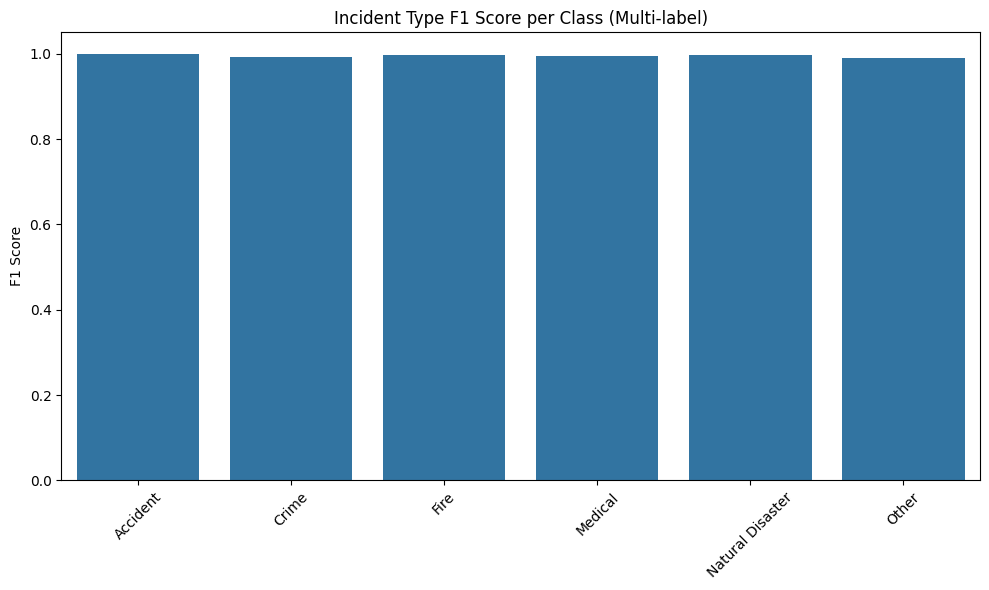

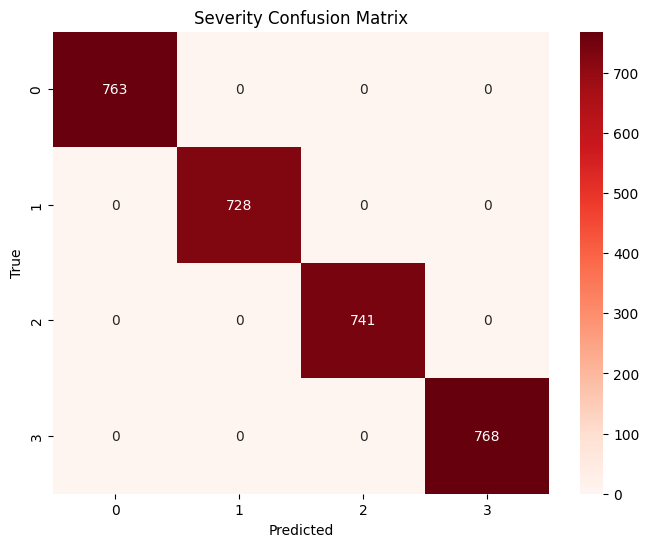

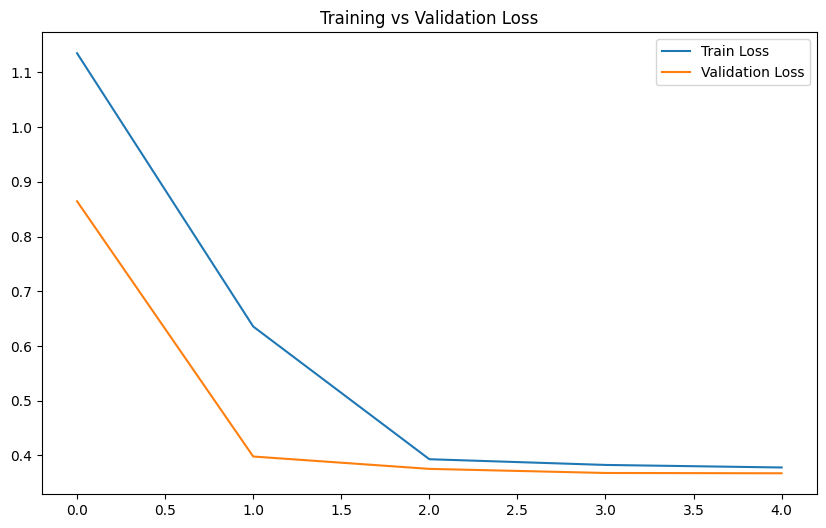

In [22]:
# --- Incident Types (multi-label) ---
y_true_types_arr = np.array(y_true_types)
y_pred_types_arr = np.array(y_pred_types)

# Per-class metrics for incident types
precisions, recalls, f1s, _ = precision_recall_fscore_support(
    y_true_types_arr, y_pred_types_arr, average=None
)

incident_type_labels = {i: label for i, label in enumerate(meta["incident_type_labels"])}

plt.figure(figsize=(10,6))
sns.barplot(x=list(incident_type_labels.values()), y=f1s)
plt.title("Incident Type F1 Score per Class (Multi-label)")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Severity (single-label) ---
cm_severity = confusion_matrix(y_true_severity, y_pred_severity)
plt.figure(figsize=(8,6))
sns.heatmap(cm_severity, annot=True, fmt="d", cmap="Reds")
plt.title("Severity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- Loss curves ---
plt.figure(figsize=(10,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

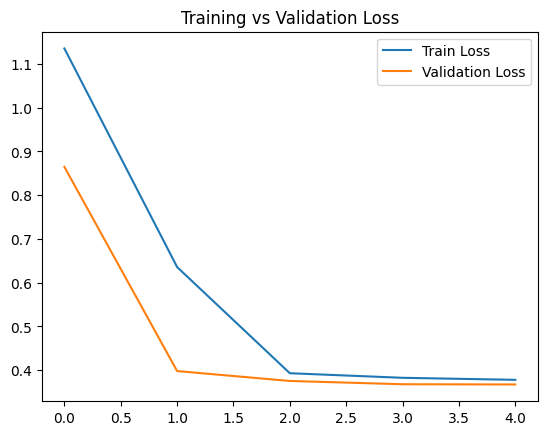

In [23]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [24]:
# Step 5.5: Over/Under-fit quick check
import numpy as np

if len(train_losses) >= 2 and len(val_losses) >= 2:
    # Recent loss trend
    train_slope = np.polyfit(range(len(train_losses)), train_losses, 1)[0]
    val_slope = np.polyfit(range(len(val_losses)), val_losses, 1)[0]
    gap = val_losses[-1] - train_losses[-1]
    gap_pct = gap / (train_losses[-1] + 1e-8) * 100

    print("=== Fit Diagnostic ===")
    print(f"Train loss last: {train_losses[-1]:.2f}")
    print(f"Val loss last:   {val_losses[-1]:.2f}")
    print(f"Gap: {gap:.2f} ({gap_pct:.1f}%)")
    print(f"Train slope: {train_slope:.2f} per epoch")
    print(f"Val slope:   {val_slope:.2f} per epoch")

    if gap_pct > 30 and val_slope < 0:
        status = "Possible overfit: val > train with narrowing trend"
    elif gap_pct > 30 and val_slope >= 0:
        status = "Overfit likely: val > train and not improving"
    elif gap_pct < -10:
        status = "Underfit unlikely: val < train (rare)"
    else:
        status = "Healthy fit"
    print(f"Status: {status}")
else:
    print("Not enough epochs to assess fit.")

=== Fit Diagnostic ===
Train loss last: 0.38
Val loss last:   0.37
Gap: -0.01 (-2.8%)
Train slope: -0.18 per epoch
Val slope:   -0.10 per epoch
Status: Healthy fit


##STEP 6: We save the lastest trained model:
After training, we save the model’s `state_dict` back into `models/emergency_model.pt`.  
This ensures that the next time we run the notebook, we can resume from the latest trained version instead of retraining from zero.


In [25]:
# Save the trained model state
checkpoint = {
    "model_state_dict": model.state_dict(),
    "incident_type_labels": meta["incident_type_labels"],
    "severity_labels": meta["severity_labels"],
    "backbone": meta.get("backbone", "xlm-roberta-base"),
    "threshold": 0.5,
}
torch.save(checkpoint, MODEL_PATH)
print("Model checkpoint saved to:", MODEL_PATH)

Model checkpoint saved to: models/emergency_model.pt
